## 01 · Data Exploration

**Goals**
1. Load the four Walmart CSV files and inspect their structure.
2. Profile missing values (focus on MarkDown columns).
3. Visualise total weekly sales over time.
4. Decompose the series into trend + seasonality + residual.
5. Analyse monthly and weekly seasonal patterns.
6. Compare sales across store types and identify holiday effects.

---
**Dataset**: Walmart Sales Forecast — `aslanahmedov/walmart-sales-forecast` (Kaggle)  
**Files**: `train.csv`, `features.csv`, `stores.csv`, `test.csv`

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_raw_data, merge_datasets
from src.config import PRIMARY_COLOR, SECONDARY_COLOR

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load Raw Data

In [2]:
train_df, features_df, stores_df = load_raw_data()

print("\n── train_df ──")
display(train_df.head(3))
print("\n── features_df ──")
display(features_df.head(3))
print("\n── stores_df ──")
display(stores_df.head())

train_df    : 421,570 rows × 5 cols
features_df :   8,190 rows × 12 cols
stores_df   :      45 rows × 3 cols

── train_df ──


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False



── features_df ──


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False



── stores_df ──


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [3]:
for name, frame in [("train_df", train_df), ("features_df", features_df), ("stores_df", stores_df)]:
    print(f"\n── {name} dtypes ──")
    print(frame.dtypes.to_string())


── train_df dtypes ──
Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool

── features_df dtypes ──
Store                    int64
Date            datetime64[us]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool

── stores_df dtypes ──
Store    int64
Type       str
Size     int64


---
## 2 · Missing Value Analysis

In [4]:
print("Missing values in features_df:")
missing = features_df.isnull().sum()
missing_pct = (missing / len(features_df) * 100).round(1)
miss_df = pd.DataFrame({"count": missing, "pct": missing_pct})
miss_df = miss_df[miss_df["count"] > 0].sort_values("pct", ascending=False)
print(miss_df.to_string())

print("\nMissing values in train_df:", train_df.isnull().sum().sum())
print("Missing values in stores_df:", stores_df.isnull().sum().sum())

Missing values in features_df:
              count   pct
MarkDown2      5269  64.3
MarkDown4      4726  57.7
MarkDown3      4577  55.9
MarkDown1      4158  50.8
MarkDown5      4140  50.5
CPI             585   7.1
Unemployment    585   7.1

Missing values in train_df: 0
Missing values in stores_df: 0


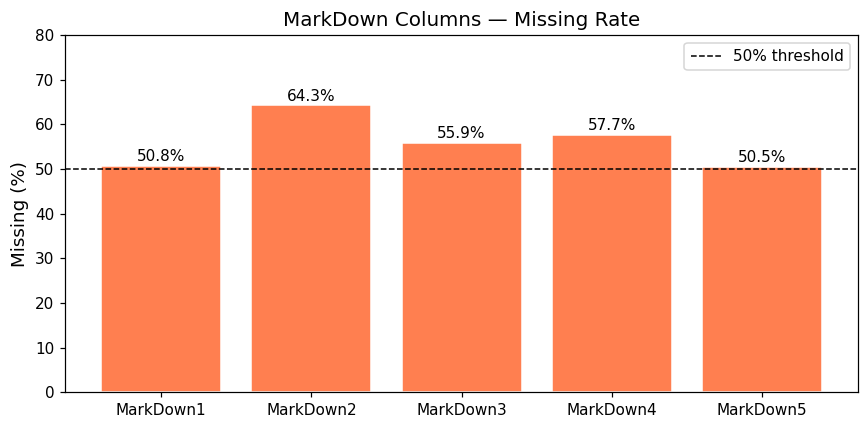

→ All MarkDown columns exceed 50% missing; will be dropped.


In [5]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
miss_pct = [(c, features_df[c].isnull().mean() * 100) for c in markdown_cols]

fig, ax = plt.subplots(figsize=(8, 4))
cols, vals = zip(*miss_pct)
bars = ax.bar(cols, vals, color=SECONDARY_COLOR, edgecolor="white")
ax.axhline(50, color="black", linestyle="--", linewidth=1, label="50% threshold")
ax.set_ylabel("Missing (%)", fontsize=12)
ax.set_title("MarkDown Columns — Missing Rate", fontsize=13)
ax.set_ylim(0, 80)
ax.legend()
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
print("→ All MarkDown columns exceed 50% missing; will be dropped.")

---
## 3 · Merge & Total Weekly Sales Trend

In [6]:
df = merge_datasets(train_df, features_df, stores_df)
df.info()
display(df.describe().T.style.background_gradient(cmap="Blues", axis=0))

Dropped MarkDown columns (>50% missing): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Merged shape : 421,570 rows × 11 cols
Date range   : 2010-02-05 → 2012-10-26
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   CPI           421570 non-null  float64       
 8   Unemployment  421570 non-null  float64       
 9   Type          421570 non-null  str           
 10  Size          421570 non-null  int64         
dtypes: bool(1), datetime64[us](1), float64(5), int64

,count,mean,min,25%,50%,75%,max,std
Store,421570.000000,22.200546,1.000000,11.000000,22.000000,33.000000,45.000000,12.785297
Dept,421570.000000,44.260317,1.000000,18.000000,37.000000,74.000000,99.000000,30.492054
Date,421570,2011-06-18 08:30:31.963375,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,nan
Weekly_Sales,421570.000000,15981.258123,-4988.940000,2079.650000,7612.030000,20205.852500,693099.360000,22711.183519
Temperature,421570.000000,60.090059,-2.060000,46.680000,62.090000,74.280000,100.140000,18.447931
Fuel_Price,421570.000000,3.361027,2.472000,2.933000,3.452000,3.738000,4.468000,0.458515
CPI,421570.000000,171.201947,126.064000,132.022667,182.318780,212.416993,227.232807,39.159276
Unemployment,421570.000000,7.960289,3.879000,6.891000,7.866000,8.572000,14.313000,1.863296
Size,421570.000000,136727.915739,34875.000000,93638.000000,140167.000000,202505.000000,219622.000000,60980.583328


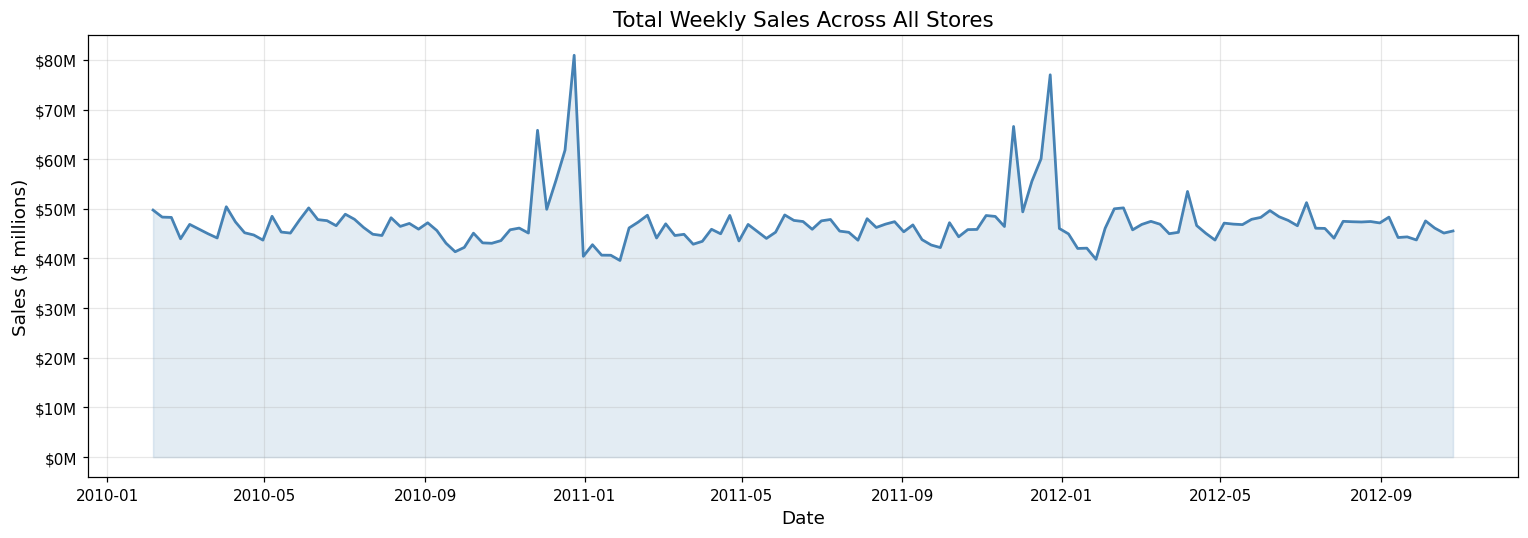

In [7]:
weekly = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly["Date"], weekly["Weekly_Sales"] / 1e6,
        color=PRIMARY_COLOR, linewidth=1.8)
ax.fill_between(weekly["Date"], weekly["Weekly_Sales"] / 1e6,
                alpha=0.15, color=PRIMARY_COLOR)
ax.set_title("Total Weekly Sales Across All Stores", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Sales ($ millions)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4 · Seasonal Decomposition

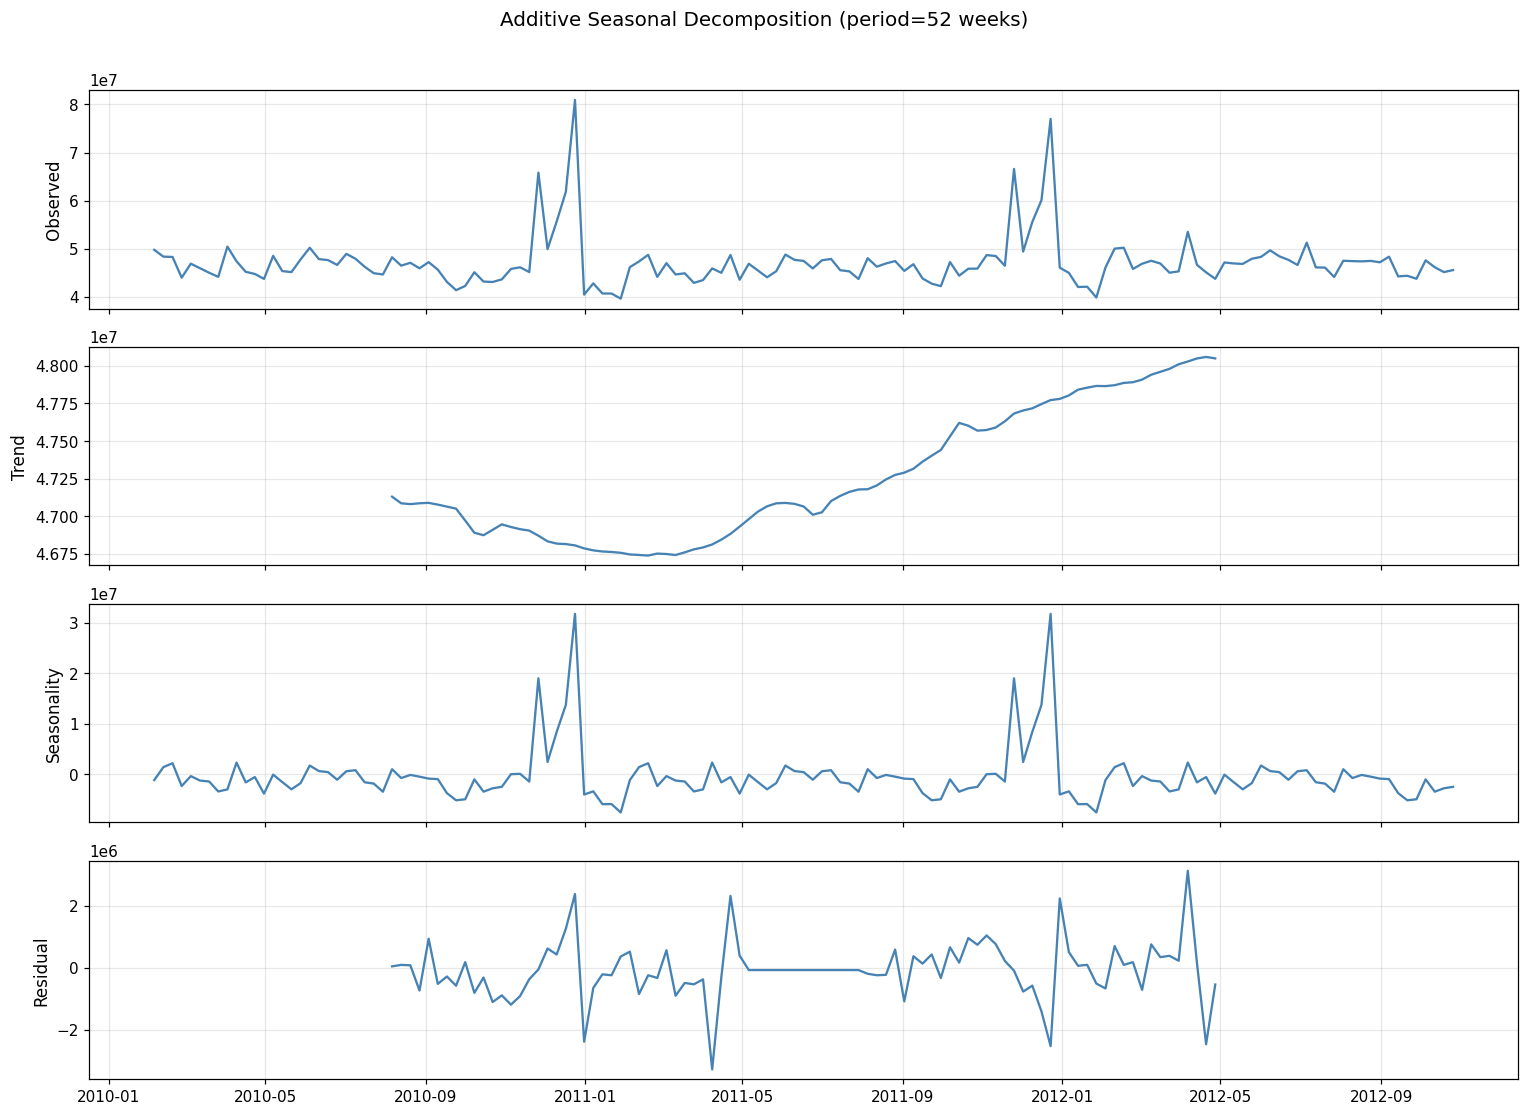

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = weekly.set_index("Date")["Weekly_Sales"]
decomp = seasonal_decompose(ts, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, data, label in zip(
    axes,
    [ts, decomp.trend, decomp.seasonal, decomp.resid],
    ["Observed", "Trend", "Seasonality", "Residual"]
):
    ax.plot(data, color=PRIMARY_COLOR, linewidth=1.5)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(alpha=0.3)
fig.suptitle("Additive Seasonal Decomposition (period=52 weeks)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5 · Rolling Averages & Trend

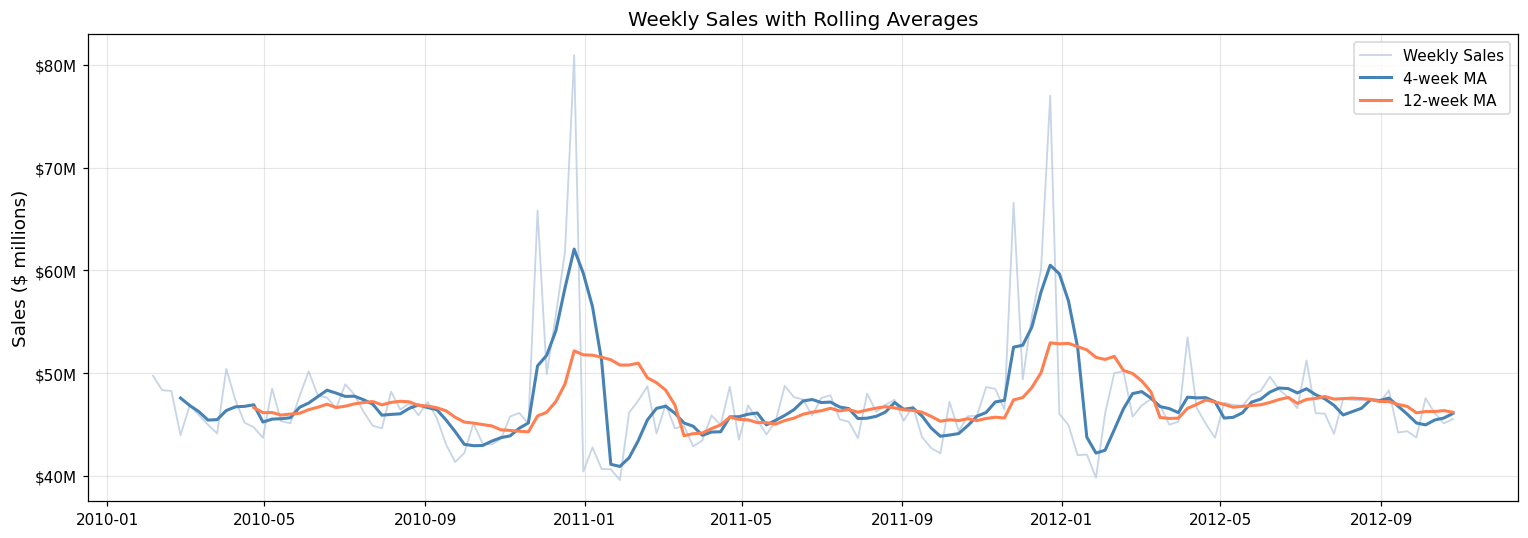

In [9]:
ts_df = weekly.set_index("Date").copy()
ts_df["MA_4"]  = ts_df["Weekly_Sales"].rolling(4).mean()
ts_df["MA_12"] = ts_df["Weekly_Sales"].rolling(12).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_df.index, ts_df["Weekly_Sales"] / 1e6,
        color="lightsteelblue", linewidth=1.2, label="Weekly Sales", alpha=0.7)
ax.plot(ts_df.index, ts_df["MA_4"]  / 1e6,
        color=PRIMARY_COLOR, linewidth=2, label="4-week MA")
ax.plot(ts_df.index, ts_df["MA_12"] / 1e6,
        color=SECONDARY_COLOR, linewidth=2, label="12-week MA")
ax.set_title("Weekly Sales with Rolling Averages", fontsize=13)
ax.set_ylabel("Sales ($ millions)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6 · Monthly and Weekly Seasonality

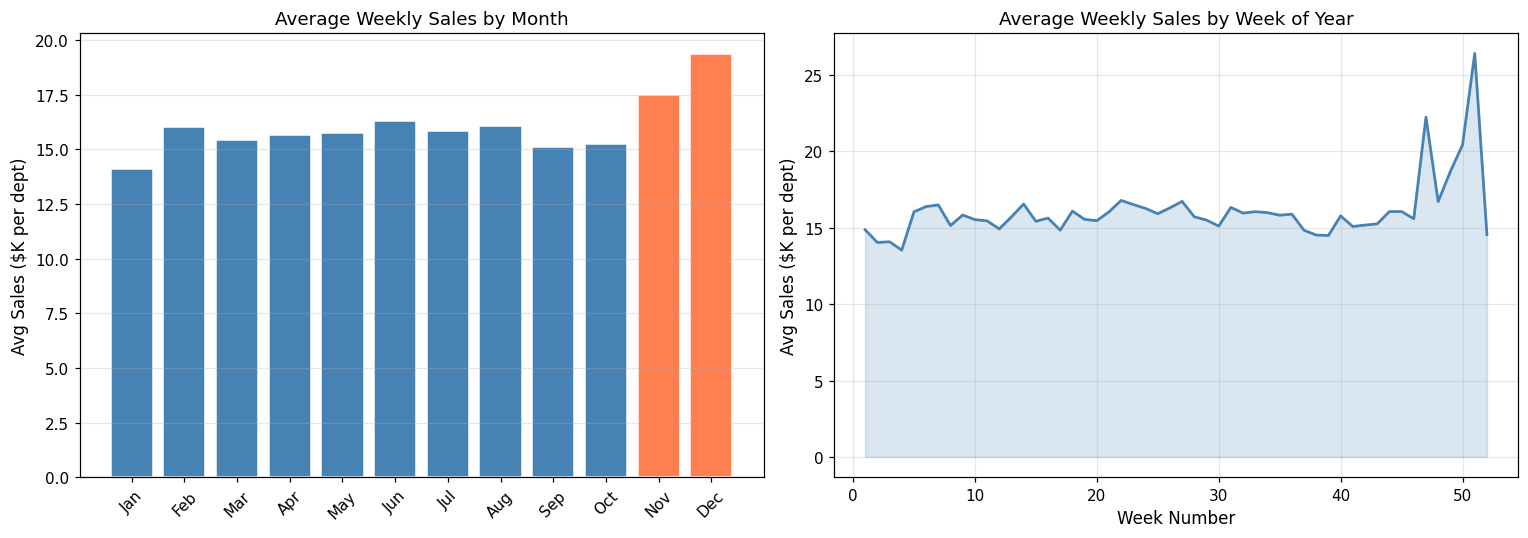

→ Strong sales spike in weeks 47–52 (Thanksgiving + Christmas season).


In [10]:
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby(df["Date"].dt.month)["Weekly_Sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly pattern
colors_m = [SECONDARY_COLOR if m in [11, 12] else PRIMARY_COLOR for m in monthly.index]
axes[0].bar(monthly.index, monthly / 1e3, color=colors_m, edgecolor="white")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title("Average Weekly Sales by Month", fontsize=12)
axes[0].set_ylabel("Avg Sales ($K per dept)", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# Weekly pattern
week_col = df["Date"].dt.strftime("%U").astype(int)
weekly_pattern = df.groupby(week_col)["Weekly_Sales"].mean()
axes[1].plot(weekly_pattern.index, weekly_pattern / 1e3,
             color=PRIMARY_COLOR, linewidth=1.8)
axes[1].fill_between(weekly_pattern.index, weekly_pattern / 1e3,
                     alpha=0.2, color=PRIMARY_COLOR)
axes[1].set_title("Average Weekly Sales by Week of Year", fontsize=12)
axes[1].set_xlabel("Week Number", fontsize=11)
axes[1].set_ylabel("Avg Sales ($K per dept)", fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Strong sales spike in weeks 47–52 (Thanksgiving + Christmas season).")

---
## 7 · Store Type Analysis & Holiday Effect

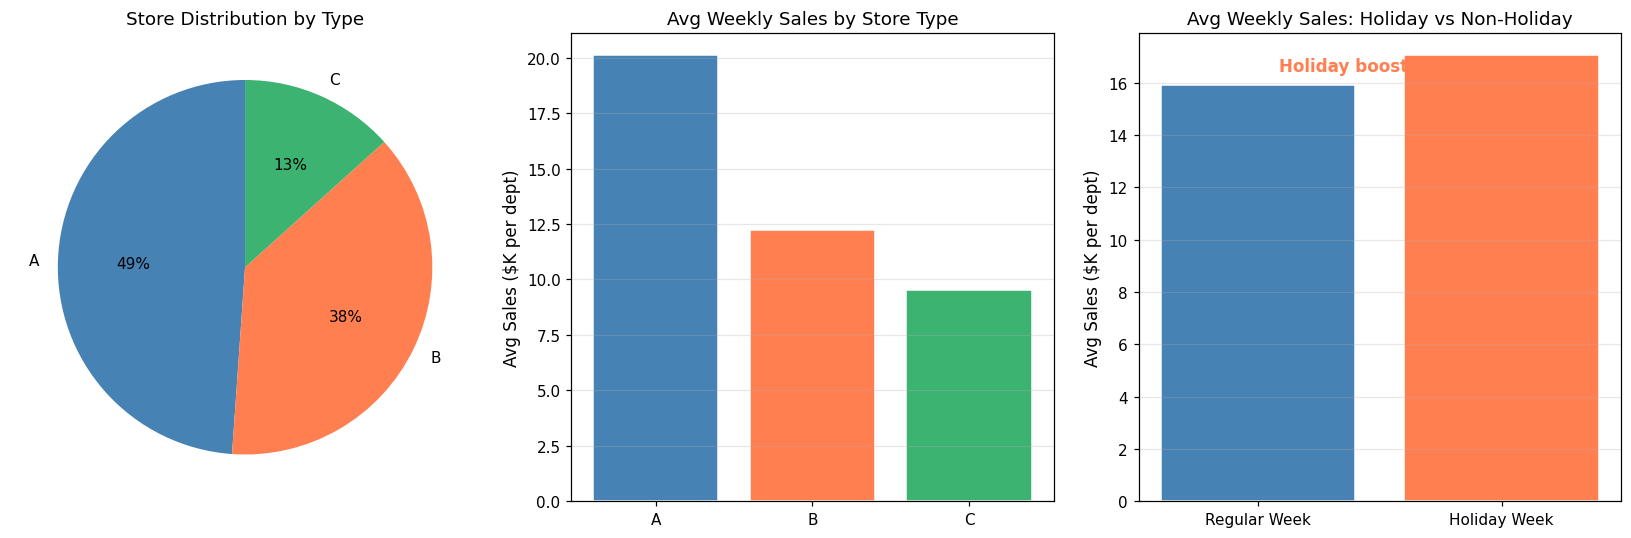

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Store type distribution
type_counts = stores_df["Type"].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct="%1.0f%%",
            colors=[PRIMARY_COLOR, SECONDARY_COLOR, "mediumseagreen"],
            startangle=90)
axes[0].set_title("Store Distribution by Type", fontsize=12)

# Average weekly sales by store type
type_sales = df.groupby("Type")["Weekly_Sales"].mean().sort_values(ascending=False)
axes[1].bar(type_sales.index, type_sales / 1e3,
            color=[PRIMARY_COLOR, SECONDARY_COLOR, "mediumseagreen"], edgecolor="white")
axes[1].set_title("Avg Weekly Sales by Store Type", fontsize=12)
axes[1].set_ylabel("Avg Sales ($K per dept)", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

# Holiday effect
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].mean()
bars = axes[2].bar(["Regular Week", "Holiday Week"], holiday_sales.values / 1e3,
                   color=[PRIMARY_COLOR, SECONDARY_COLOR], edgecolor="white")
axes[2].set_title("Avg Weekly Sales: Holiday vs Non-Holiday", fontsize=12)
axes[2].set_ylabel("Avg Sales ($K per dept)", fontsize=11)
axes[2].grid(axis="y", alpha=0.3)
diff_pct = (holiday_sales[True] - holiday_sales[False]) / holiday_sales[False] * 100
axes[2].text(0.5, 0.92, f"Holiday boost: +{diff_pct:.1f}%",
             transform=axes[2].transAxes, ha="center", fontsize=11,
             color=SECONDARY_COLOR, fontweight="bold")

plt.tight_layout()
plt.show()

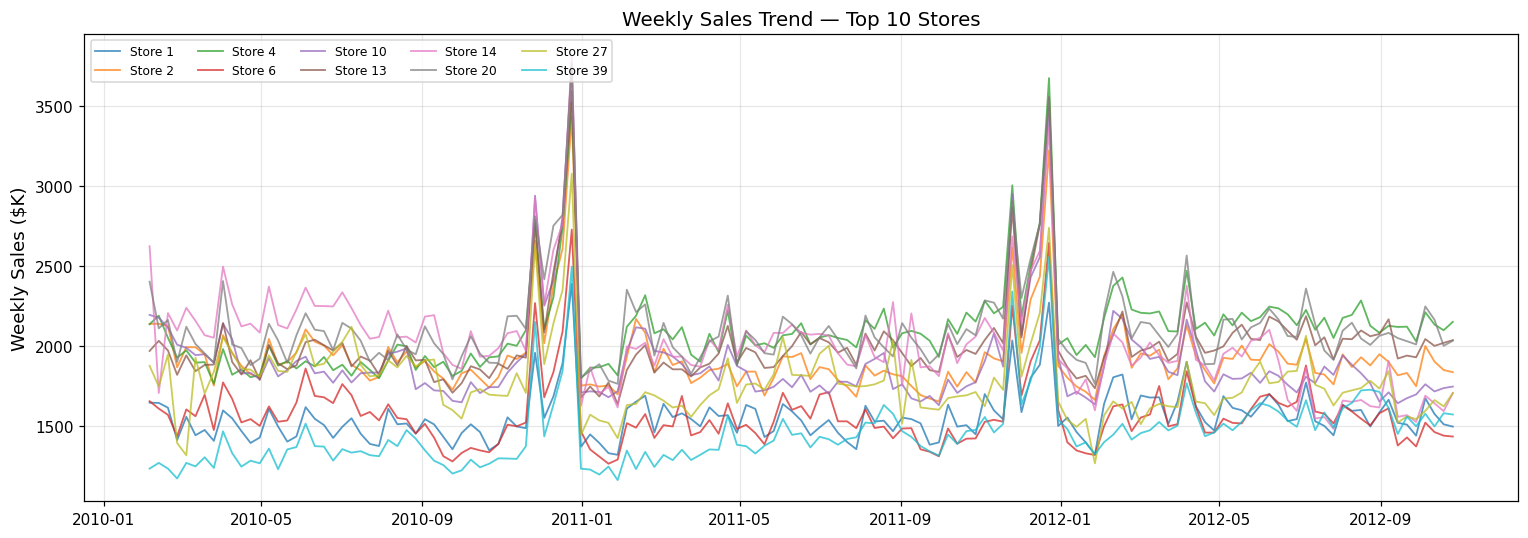

In [12]:
# Top-10 stores by total sales
top_stores = df.groupby("Store")["Weekly_Sales"].sum().nlargest(10).index
store_ts = df[df["Store"].isin(top_stores)].groupby(["Date", "Store"])["Weekly_Sales"].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
for col in store_ts.columns:
    ax.plot(store_ts.index, store_ts[col] / 1e3, linewidth=1.2, alpha=0.75, label=f"Store {col}")
ax.set_title("Weekly Sales Trend — Top 10 Stores", fontsize=13)
ax.set_ylabel("Weekly Sales ($K)", fontsize=12)
ax.legend(fontsize=8, ncol=5, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Key Observations

| # | Finding | Detail |
|---|---------|--------|
| 1 | Data size | 421,570 weekly store-dept records across 45 stores, up to 81 depts (2010-02 – 2012-10) |
| 2 | MarkDown columns | All 5 exceed 50% missing (MarkDown2: 64.3%, MarkDown1: 50.8%) → **dropped** |
| 3 | External feature gaps | CPI and Unemployment each have 585 NaN (7.1%) — merge gaps, not source data |
| 4 | Strong seasonality | Total weekly sales spike to ~$80M in weeks 47–52 (Thanksgiving + Christmas) |
| 5 | Holiday boost | Holiday weeks average **+7.1% higher** sales than regular weeks |
| 6 | Store type disparity | Type A stores average ~3× the weekly sales of Type C stores |
| 7 | Stable overall trend | Rolling MA-12 is nearly flat — no strong upward or downward drift over 2010–2012 |

### Expected Impact on Later Notebooks

| Observation | Expected downstream effect |
|-------------|---------------------------|
| Weekly seasonality spike (weeks 47–52) | `Week` and `Month` features will rank highly in tree models; holiday flags add extra signal |
| Year-over-year sales stability | `Sales_Lag_52` should be among the highest-correlated lag features |
| Store type disparity (A >> C) | `Store`, `Dept`, `Size`, and `Type` dummies will be important in XGBoost/LightGBM |
| CPI / Unemployment NaN gaps | `fill_missing_externals()` forward/back-fills per store, closing all 585 NaN |
| All MarkDowns > 50% missing | Confirmed correct to drop them entirely in `merge_datasets()` |

**Next**: `02_preprocessing.ipynb` — merge datasets, handle missing externals, validate the time split.